# Classic Iris Dataset Problem

In [1]:
pip install numpy matplotlib scipy scikit-learn pandas seaborn 


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn import datasets

In [3]:
data = datasets.load_iris()

#dataset is a dictionary-like object that contains the data and metadata of the iris dataset. 
#The keys of the dataset include 'data', 'target', 'target_names', 'DESCR', 'feature_names', and 'filename'. 
# Each key corresponds to a specific aspect of the dataset, such as the actual data, the target labels, the names of the target classes, a description of the dataset, the names of the features, and the filename where the dataset is stored.

In [4]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
data['data'][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [6]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

What problem are we trying to solve?

-> We are trying to use attributes of flowers to predict the species of the flowers
-> specifically using the sepal length and width and the petal length and width to predict if an Iris flower is of type ___

# EDA 

In [9]:
df = pd.DataFrame(data['data'], columns=data['feature_names'])
df['target'] = data['target']
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


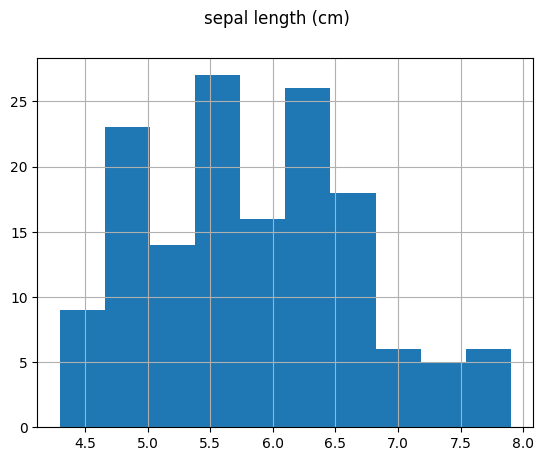

In [11]:
col = 'sepal length (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

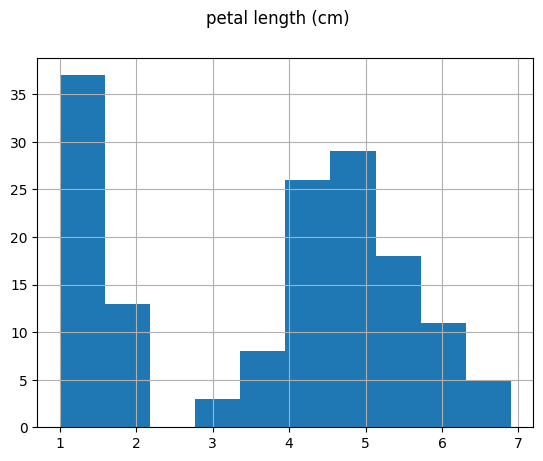

In [12]:
col = 'petal length (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

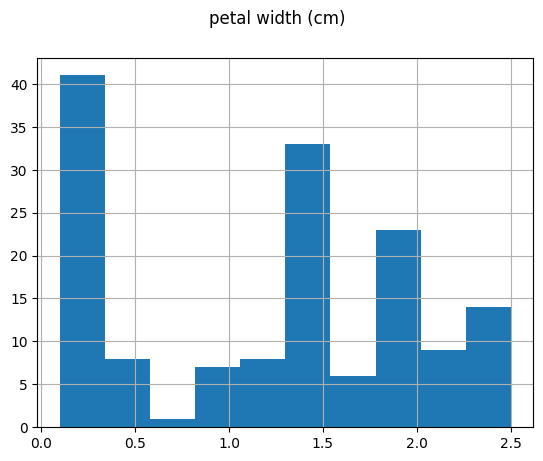

In [13]:
col = 'petal width (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

# Relationship of data features with the target

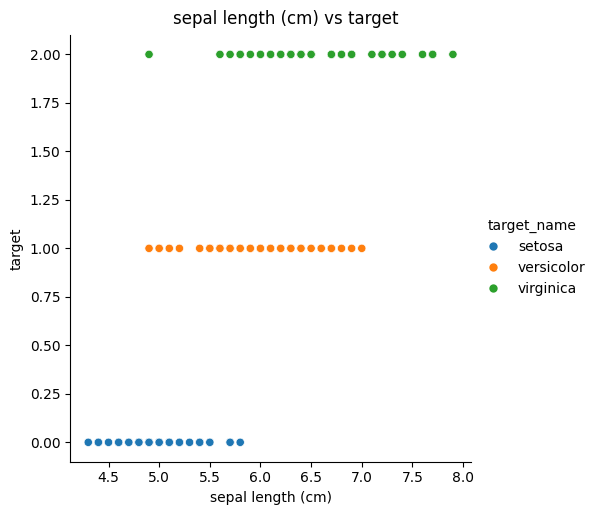

In [14]:
sns.relplot(x='sepal length (cm)', y='target', hue='target_name', data=df)
_ = plt.suptitle('sepal length (cm) vs target', y = 1.02)

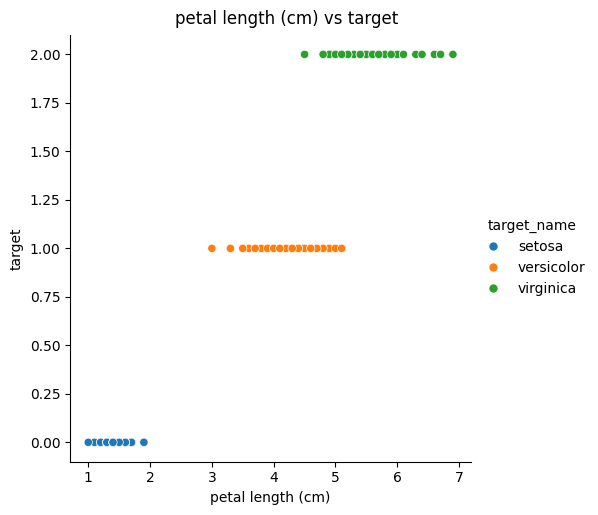

In [15]:
sns.relplot(x='petal length (cm)', y='target', hue='target_name', data=df)
_ = plt.suptitle('petal length (cm) vs target', y = 1.02)

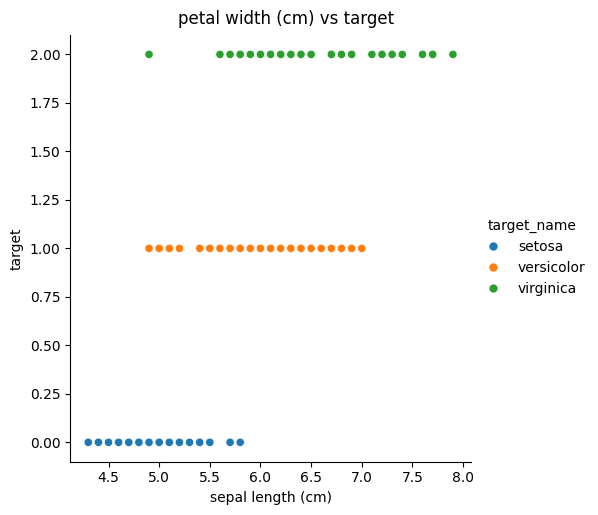

In [16]:
sns.relplot(x='sepal length (cm)', y='target', hue='target_name', data=df)
_ = plt.suptitle('petal width (cm) vs target', y = 1.02)

# EDA: Pairplots

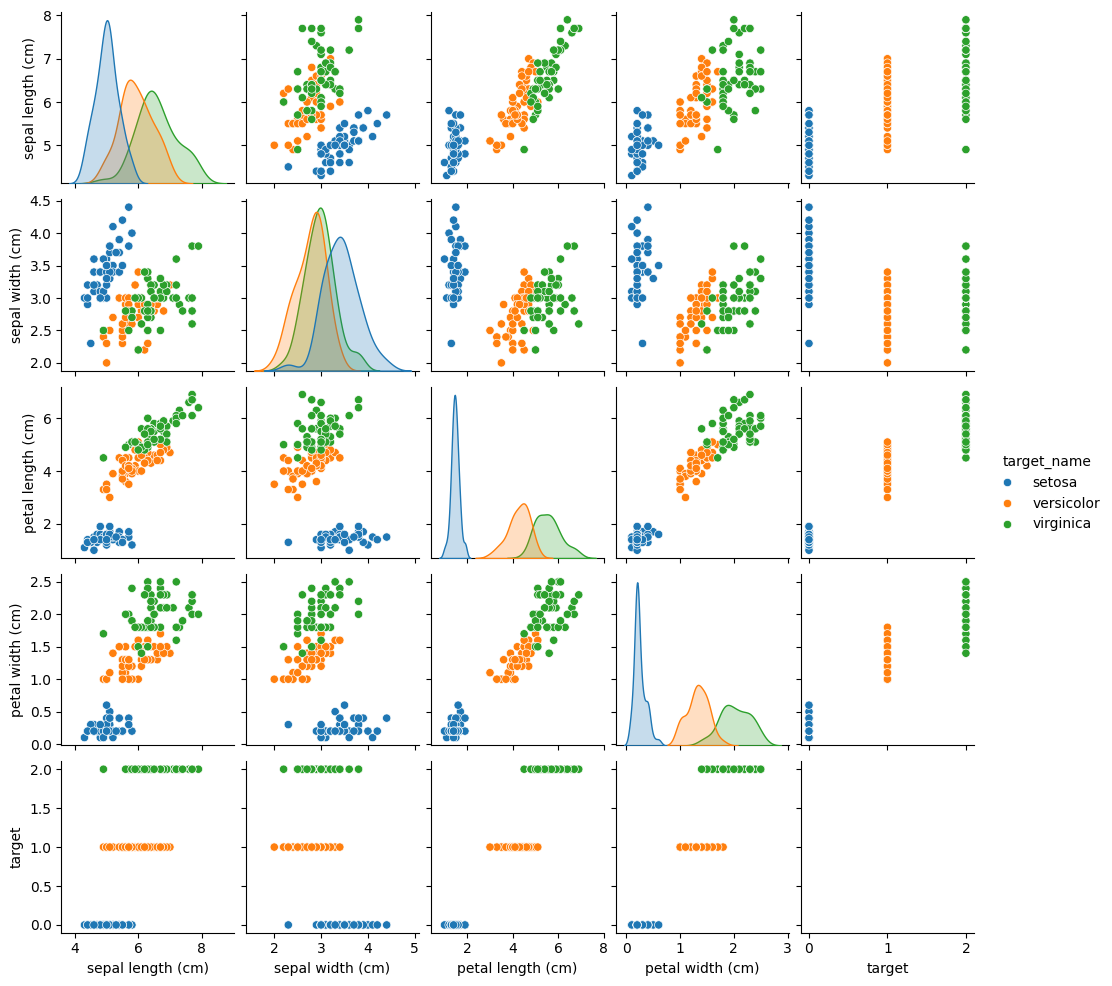

In [17]:
sns.pairplot(df, hue= 'target_name', height = 2)

## Train test split

always want to evaluate final model on unseen test set in the training process.
This might be less true if using cross-validation, still consider it best practice

In [18]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state = 42)

In [19]:
df_train.shape

(112, 6)

In [20]:
df_test.shape

(38, 6)

In [21]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
4,5.0,3.6,1.4,0.2,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa
142,5.8,2.7,5.1,1.9,2,virginica
85,6.0,3.4,4.5,1.6,1,versicolor
86,6.7,3.1,4.7,1.5,1,versicolor


# Prepare data for modelling
### involves splitting our data back out into plain NumPy arrays

In [22]:
X_train = df_train.drop(['target','target_name'], axis = 1).values
y_train = df_train['target'].values

In [23]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
4,5.0,3.6,1.4,0.2,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa
142,5.8,2.7,5.1,1.9,2,virginica
85,6.0,3.4,4.5,1.6,1,versicolor
86,6.7,3.1,4.7,1.5,1,versicolor


In [24]:
X_train

array([[5. , 3.6, 1.4, 0.2],
       [5.2, 4.1, 1.5, 0.1],
       [5.8, 2.7, 5.1, 1.9],
       [6. , 3.4, 4.5, 1.6],
       [6.7, 3.1, 4.7, 1.5],
       [5.4, 3.9, 1.3, 0.4],
       [5.4, 3.7, 1.5, 0.2],
       [5.5, 2.4, 3.7, 1. ],
       [6.3, 2.8, 5.1, 1.5],
       [6.4, 3.1, 5.5, 1.8],
       [6.6, 3. , 4.4, 1.4],
       [7.2, 3.6, 6.1, 2.5],
       [5.7, 2.9, 4.2, 1.3],
       [7.6, 3. , 6.6, 2.1],
       [5.6, 3. , 4.5, 1.5],
       [5.1, 3.5, 1.4, 0.2],
       [7.7, 2.8, 6.7, 2. ],
       [5.8, 2.7, 4.1, 1. ],
       [5.2, 3.4, 1.4, 0.2],
       [5. , 3.5, 1.3, 0.3],
       [5.1, 3.8, 1.9, 0.4],
       [5. , 2. , 3.5, 1. ],
       [6.3, 2.7, 4.9, 1.8],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [5.6, 2.7, 4.2, 1.3],
       [5.1, 3.4, 1.5, 0.2],
       [5.7, 3. , 4.2, 1.2],
       [7.7, 3.8, 6.7, 2.2],
       [4.6, 3.2, 1.4, 0.2],
       [6.2, 2.9, 4.3, 1.3],
       [5.7, 2.5, 5. , 2. ],
       [5.5, 4.2, 1.4, 0.2],
       [6. , 3

In [25]:
y_train

array([0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 2])

## What is our baseline?

in this case our model is randomly guessing the species of flower, or guessing a single species for every data point, we would expect to have a model accuracy
of 0.33 or 33%, since we have 3 different classes that are evenly balanced.

Lets look at our dataset and decide some cutoff points for classification


In [26]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [27]:
df_train.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'target_name'],
      dtype='str')

In [28]:
def single_feature_prediction(petal_length):
    if petal_length < 2.5:
        return 0
    elif petal_length < 4.8:
        return 1
    else:
        return 2


#simplest model

In [29]:
X_train[:,2]

array([1.4, 1.5, 5.1, 4.5, 4.7, 1.3, 1.5, 3.7, 5.1, 5.5, 4.4, 6.1, 4.2,
       6.6, 4.5, 1.4, 6.7, 4.1, 1.4, 1.3, 1.9, 3.5, 4.9, 1.9, 1.6, 1.7,
       4.2, 1.5, 4.2, 6.7, 1.4, 4.3, 5. , 1.4, 4.8, 5.1, 4. , 4.5, 5.4,
       4. , 1.7, 3.3, 5.3, 1.4, 1.2, 3.8, 5. , 1.5, 5.1, 1.5, 1.6, 4.8,
       3. , 5.7, 5.1, 5.6, 6.1, 4. , 1.4, 1.1, 5. , 6. , 1.5, 1.4, 1.3,
       4.9, 5.6, 1.4, 5.5, 6. , 1.3, 4.7, 4.6, 4.8, 4.7, 5.3, 1.6, 5.4,
       4.2, 5.2, 3.5, 3.9, 4.6, 1.3, 4.6, 4.4, 1.5, 4.1, 6.3, 5.7, 1.5,
       3.3, 5.7, 5.8, 1.4, 5.6, 1.4, 4.9, 6.1, 5.6, 4.1, 5.5, 4.4, 4.3,
       4.9, 5.1, 1.7, 4. , 4.5, 1.2, 4. , 5.9])

In [30]:
manual_y_predictions = np.array([single_feature_prediction(val) for val in X_train[:,2]])

In [31]:
manual_y_predictions

array([0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 2, 0, 2, 0, 0, 2, 1, 2, 2, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 2,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 1, 0,
       1, 2])

In [32]:
manual_model_accuracy = np.mean(manual_y_predictions == y_train)

In [33]:
print(f"Manual model accuracy: {manual_model_accuracy * 100:.2f}%")

Manual model accuracy: 94.64%


# Modelling - Logistic Regression

In [34]:
model = LogisticRegression(max_iter = 200)

In [35]:
#Xt - 'X_train', Xv = 'X_validation'
Xt, Xv, yt, yv = train_test_split(X_train, y_train, test_size = 0.25)

In [36]:
model.fit(Xt, yt)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred = model.predict(Xv)
y_pred

array([1, 2, 1, 0, 1, 1, 1, 2, 2, 1, 0, 2, 2, 2, 0, 1, 0, 2, 1, 2, 1, 1,
       0, 0, 1, 2, 0, 2])

In [38]:
yv

array([1, 2, 1, 0, 1, 1, 1, 2, 2, 1, 0, 2, 2, 2, 0, 1, 0, 2, 1, 2, 1, 1,
       0, 0, 1, 2, 0, 2])

In [39]:
np.mean(y_pred == yv)

np.float64(1.0)

In [40]:
model.score(Xv, yv)

1.0

## Using cross-validation to evaluate our model

In [41]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [42]:
model = LogisticRegression(max_iter=200)

In [43]:
# cross_val_score
accuracies = cross_val_score(model, X_train, y_train, cv = 5, scoring = 'accuracy')

In [ ]:
np.mean(accuracies)

np.float64(0.9636363636363636)

: 